# Exploratory Data Analysis (EDA)


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
train=pd.read_csv('../dataset/train.csv')
store=pd.read_csv('../dataset/store.csv')

C:\Users\nadab\AppData\Local\Temp\ipykernel_10844\2768291744.py:1: DtypeWarning: Columns (7: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv('../dataset/train.csv')


# 1. Basic Exploration

In [74]:
print("train shape:",train.shape) #returns the number of rows and columns in the train dataset
print("store shape:",store.shape) #returns the number of rows and columns in the store dataset

train shape: (1017209, 9)
store shape: (1115, 10)


In [75]:
train.info() #returns information about the train dataset

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [76]:
store.info() #returns information about the store dataset

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [98]:
train.describe() #returns statistical summary of the train dataset

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [99]:
store.describe() #returns statistical summary of the store dataset

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


# 2. Date Preparation

In [100]:
train["Date"] = pd.to_datetime(train["Date"]) #converts the date column to datetime format
train.info() #returns information about the train dataset after converting the date column to datetime format

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
 9   Month          1017209 non-null  period[M]     
dtypes: datetime64[us](1), int64(7), object(1), period[M](1)
memory usage: 77.6+ MB


# 3. Missing Values

In [77]:
print("missing values in train dataset:\n",train.isnull().sum()) #returns the number of missing values in the train dataset
print("missing values in store dataset:\n",store.isnull().sum()) #returns the number of missing values in the store dataset

missing values in train dataset:
 Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64
missing values in store dataset:
 Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [78]:
print("missing percentage in train dataset:\n",(train.isnull().sum()/len(train)*100).round(2)) #returns the percentage of missing values in the train dataset
print("missing percentage in store dataset:\n",(store.isnull().sum()/len(store)*100).round(2)) #returns the percentage of missing values in the store dataset

missing percentage in train dataset:
 Store            0.0
DayOfWeek        0.0
Date             0.0
Sales            0.0
Customers        0.0
Open             0.0
Promo            0.0
StateHoliday     0.0
SchoolHoliday    0.0
dtype: float64
missing percentage in store dataset:
 Store                         0.00
StoreType                     0.00
Assortment                    0.00
CompetitionDistance           0.27
CompetitionOpenSinceMonth    31.75
CompetitionOpenSinceYear     31.75
Promo2                        0.00
Promo2SinceWeek              48.79
Promo2SinceYear              48.79
PromoInterval                48.79
dtype: float64


# 4. Duplicates

In [79]:
print("duplicate rows in train dataset:",train.duplicated().sum()) #returns the number of duplicate rows in the train dataset
print("duplicate rows in store dataset:",store.duplicated().sum()) #returns the number of duplicate rows in the store dataset

duplicate rows in train dataset: 0
duplicate rows in store dataset: 0


# 5. Trends and Seasonality

In [83]:
daily_sales = train.groupby('Date')['Sales'].sum() #groups the train dataset by date and sums the sales for each date

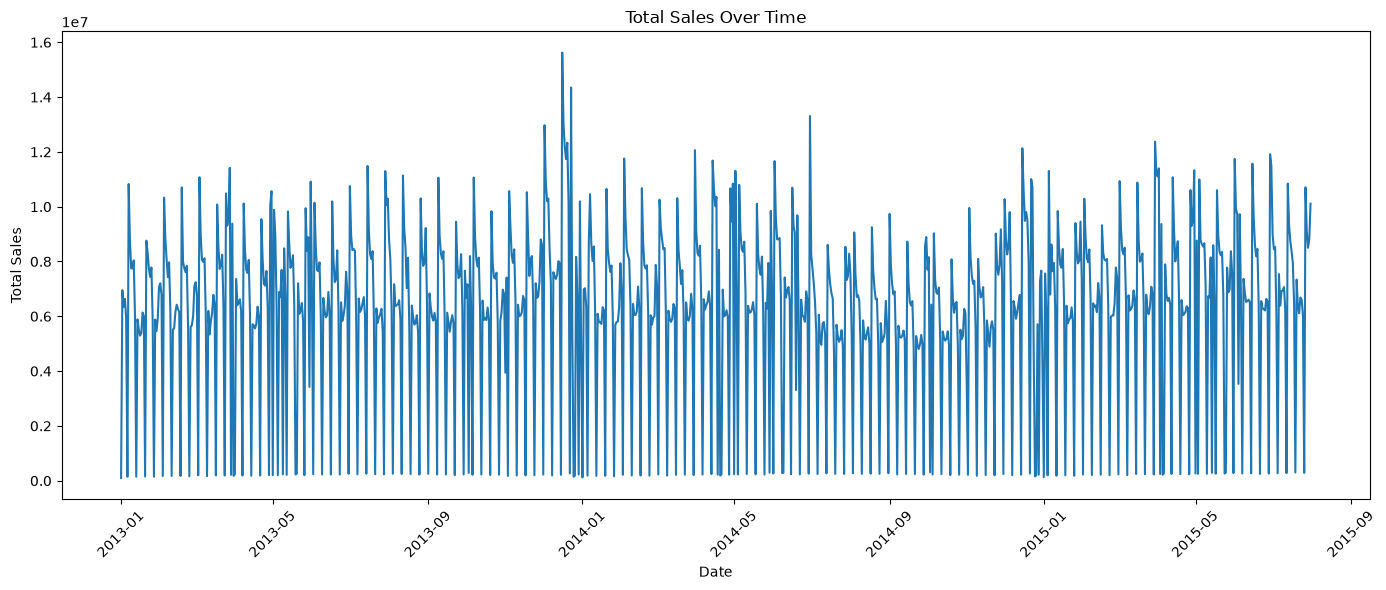

In [84]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
train["Month"] = train["Date"].dt.to_period('M') #extracts the month from the date column and creates a new column for it

In [86]:
monthly_sales = train.groupby('Month')['Sales'].sum() #groups the train dataset by month and sums the sales for each month

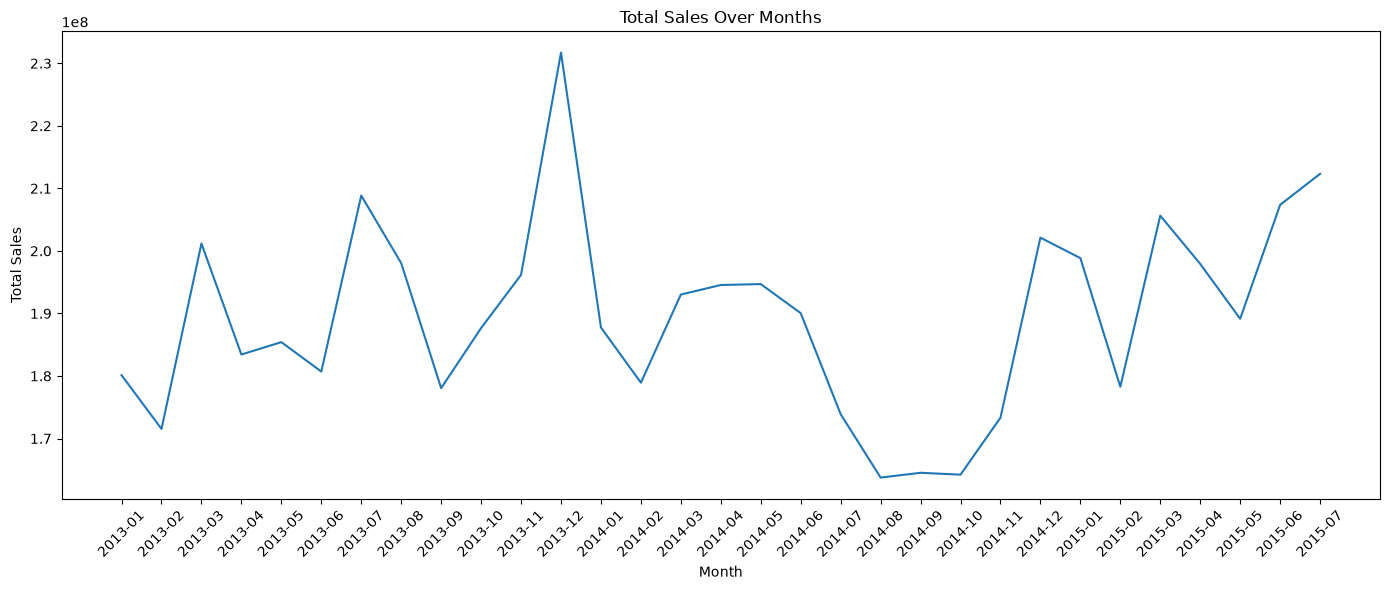

In [87]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title('Total Sales Over Months')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Finding:
Total sales fluctuate over time,with noticeable increases and decreases across different months.This indicates that sales vary throughout the year.

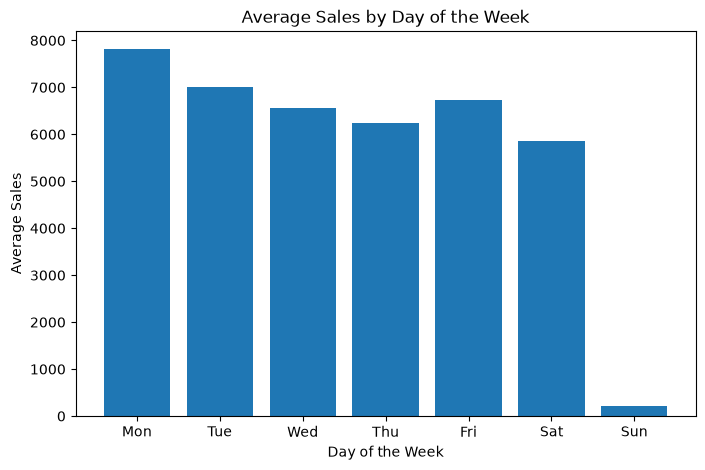

In [88]:
sales_by_day=train.groupby('DayOfWeek')['Sales'].mean() #groups the train dataset by day of the week and calculates the mean sales for each day
plt.figure(figsize=(8,5))
plt.bar(sales_by_day.index, sales_by_day.values)
plt.title('Average Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Sales')
plt.xticks(range(1,8), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

Finding:
Average sales vary across the days of the week.Some days have noticeably higher average sales than others.

# 6. Realationship and Correlations

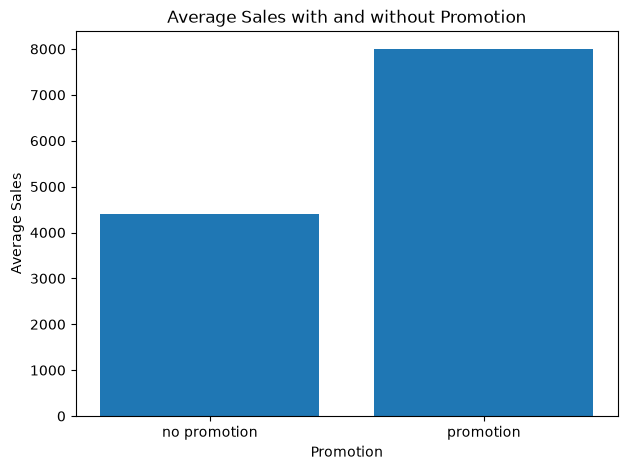

In [89]:
promo_sales=train.groupby('Promo')['Sales'].mean() #groups the train dataset by promo and calculates the mean sales for each promo
plt.figure(figsize=(7,5))
plt.bar(["no promotion","promotion"], promo_sales.values)
plt.title('Average Sales with and without Promotion')
plt.xlabel('Promotion')
plt.ylabel('Average Sales')
plt.show()

Finding:
The average sales are higher on days when a promotion is active compared with days without a promotion.

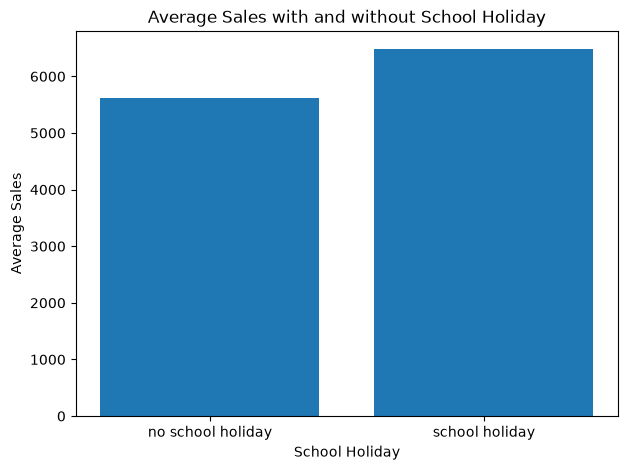

In [90]:
holiday_sales=train.groupby('SchoolHoliday')['Sales'].mean() #groups the train dataset by state holiday and calculates the mean sales for each state holiday
plt.figure(figsize=(7,5))
plt.bar(["no school holiday","school holiday"], holiday_sales.values)
plt.title('Average Sales with and without School Holiday')
plt.xlabel('School Holiday')
plt.ylabel('Average Sales')
plt.show()

Finding:
The average sales are higher on school holidays compared to non-school holidays.

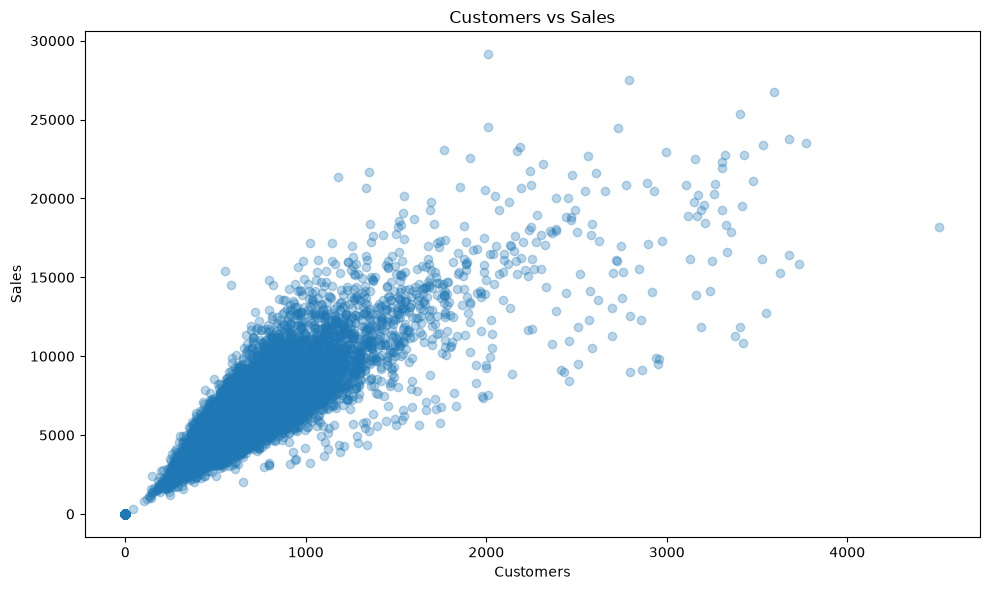

In [101]:
sample=train.sample(10000 , random_state=42)
plt.figure(figsize=(10,6))
plt.scatter(sample["Customers"],sample["Sales"],alpha=0.3)
plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Finding:
Customers and Sales show a strong positive realtionship: as customer count rises, sales rise too,though the spread widens at higher customer counts.


In [102]:
correlation= train[['Sales','Customers']].corr()
correlation

,Sales,Customers
Sales,1.000000,0.894711
Customers,0.894711,1.000000


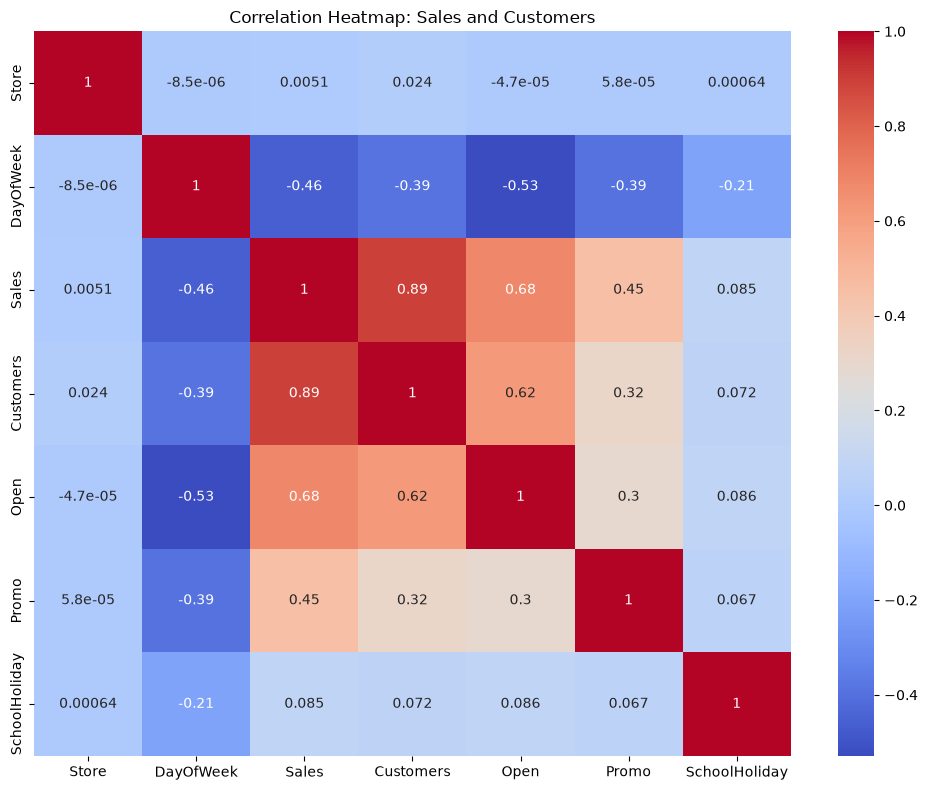

In [103]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap: Sales and Customers")
plt.tight_layout()
plt.show()

Finding:
Sales is strongly correlated with Customers (0.89), and moderately with Open (0.68) and Promo (0.45), while DayOfWeek is negatively correlated (-0.46) and Store and SchoolHoliday show almost no relationship.

# 7. Sales Distribution and Outliers

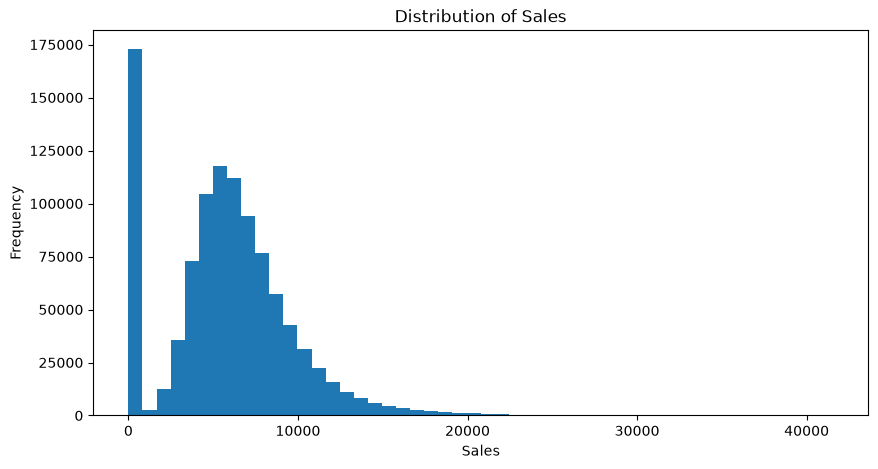

In [91]:
plt.figure(figsize=(10,5))
plt.hist(train["Sales"],bins=50)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Finding:
Sales are concentrated mainly in the lower to middle range with a long right tail toward higher sales values, There are also many records with zero sales indicating days when stores had no recorded sales.

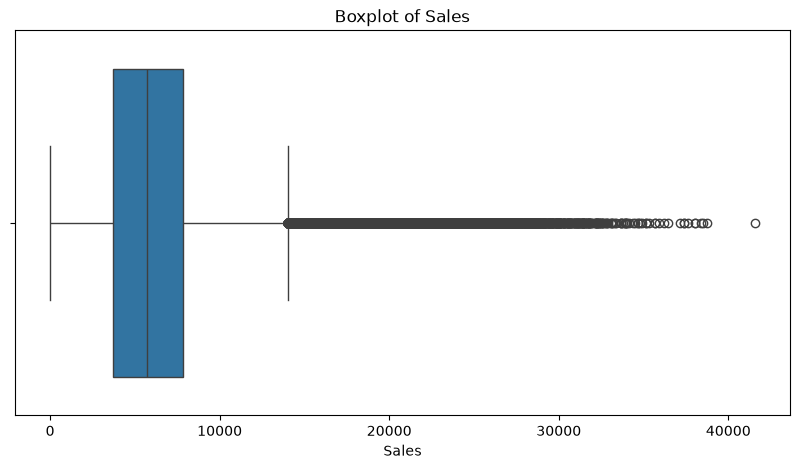

In [92]:
plt.figure(figsize=(10,5))
sns.boxplot(x=train["Sales"])
plt.title("Boxplot of Sales")
plt.xlabel("Sales")
plt.show()

Finding:
The boxplot shows several high sales outliers beyond the upper whisker.This indicates that some store days had unusual high sales compared with the majority of observations.